<a href="https://colab.research.google.com/github/WR2233/notes/blob/main/assignment_2026-04-16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# まずは必要になるpythonモジュールのライブラリファイルをコピーし、すべてインポートしておく
import os
import sys
import shutil
import tarfile
from google.colab import drive
drive.mount('/content/gdrive')
shutil.copy('/content/gdrive/MyDrive/qcintro.tar.gz', '.')
with tarfile.open('qcintro.tar.gz', 'r:gz') as tar:
    tar.extractall(path='/root/.local')

sys.path.append('/root/.local/lib/python3.12/site-packages')

Mounted at /content/gdrive


/tmp/ipykernel_26526/1995156235.py:10: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/root/.local')


In [2]:
# まずは全てインポート
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, Bounds
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler

print('notebook ready')

notebook ready


In [3]:
simulator = AerSimulator()
sampler = Sampler()
print(simulator.name)

aer_simulator


## 問題１：シミュレータを使う

In [16]:
circuits = []

##################
### EDIT BELOW ###
##################

#講義と同様に4通りの回路を用意し、circuitsに編入する

# 回路I
circuit = QuantumCircuit(2, name= 'circuti_I')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-np.pi/4., 1)
circuit.measure_all()
circuits.append(circuit)

# 回路II
circuit = QuantumCircuit(2, name= 'circuti_II')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-3*np.pi/4., 1)
circuit.measure_all()
circuits.append(circuit)

# 回路III
circuit = QuantumCircuit(2, name= 'circuti_III')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-np.pi/4., 1)
circuit.ry(-np.pi/2., 0)
circuit.measure_all()
circuits.append(circuit)

# 回路IV
circuit = QuantumCircuit(2, name= 'circuti_IV')
circuit.h(0)
circuit.cx(0,1)
circuit.ry(-3*np.pi/4., 1)
circuit.ry(-np.pi/2., 0)
circuit.measure_all()
circuits.append(circuit)

print("end of making circuits")

##################
### EDIT ABOVE ###
##################


end of making circuits


In [14]:
# シミュレータにはショット数の制限がないので、時間の許す限りいくらでも大きい値を使っていい
shots = 100000

# 実習と同じく transpile() - 今は「おまじない」と思ってよい
circuits = transpile(circuits, backend=simulator)
# シミュレータもバックエンドと同じように振る舞うので、runメソッドで回路とショット数を受け取り、ジョブオブジェクトを返す
job = sampler.run(circuits, shots=shots)

# シミュレータから渡されたジョブオブジェクトは実機のジョブと全く同じように扱える
result = job.result()

c_arr = np.zeros(4, dtype=float)

##################
### EDIT BELOW ###
##################

#講義と同様にSamplerの結果からc_arrを計算する
counts_list = []

for idx in range(4):
  counts = result[idx].data.meas.get_counts()
  counts_list.append(counts)

for ic, counts in enumerate(counts_list):
  c_arr[ic] = counts.get('00', 0) + counts.get('11', 0) - counts.get('01', 0) - counts.get('10', 0)
##################
### EDIT ABOVE ###
##################

c_arr /= shots

s_val = c_arr[0] - c_arr[1] + c_arr[2] + c_arr[3]
print('S =', s_val)

S = 2.8290200000000003


## 問題２：Ryの角度を連続的に変える

ここまで測定の直前のRyゲートの引数に特定の値のみ使ってきましたが、この角度を細かく変えていくとどうなるでしょうか。

In [53]:
# thetaとchiそれぞれについて、20点を考える（計400点）
ntheta = 20
nchi = 20

thetas = np.linspace(0., np.pi, ntheta)
chis = np.linspace(0., np.pi, nchi)

# それぞれの(theta, chi)ペアに対して回路を作る
circuits = []
# np.ndindexは多次元配列に対して整数値を返す
# -> idx = (0, 0), (0, 1), ..., (1, 0), (1, 1), ...
for idx in np.ndindex(ntheta, nchi):
    theta = thetas[idx[0]]
    chi = chis[idx[1]]
    circuit = QuantumCircuit(2, name=f'circuit_{idx[0]}_{idx[1]}')

    # ベル状態を作り、thetaとchiを引数に持つRyゲートをかける回路を作る

    ##################
    ### EDIT BELOW ###
    ##################
    circuit.h(0)
    circuit.cx(0,1)
    circuit.ry(theta, 1)
    circuit.ry(chi, 0)

    ##################
    ### EDIT ABOVE ###
    ##################

    circuit.measure_all()

    circuits.append(circuit)

# Execute all circuits in Sampler and retrieve the results
shots = 100000
circuits = transpile(circuits, backend=simulator)
job = sampler.run(circuits, shots=shots)
result = job.result()

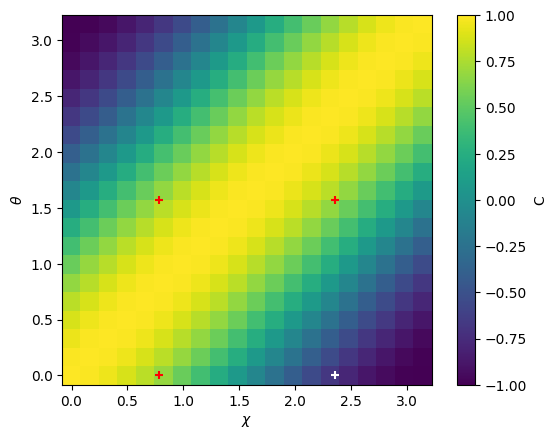

In [54]:


# それぞれの(theta, chi)ペアについてCの値を計算する
c_values = np.zeros((ntheta, nchi), dtype=float)
for icirc, idx in enumerate(np.ndindex(ntheta, nchi)):

    counts = result[icirc].data.meas.get_counts()

    ##################
    ### EDIT BELOW ###
    ##################

    c_values[idx] = counts.get('00', 0) + counts.get('11', 0) - counts.get('01', 0) - counts.get('10', 0)

    ##################
    ### EDIT ABOVE ###
    ##################
c_values /= shots

# Making a 2D plot using imshow()
# The theta dimension of c_values must be reversed because imshow() puts the origin at the top left corner
dtheta = (thetas[1] - thetas[0]) * 0.5
dchi = (chis[1] - chis[0]) * 0.5
plt.imshow(c_values[::-1], extent=(chis[0] - dchi, chis[-1] + dchi, thetas[0] - dtheta, thetas[-1] + dtheta))
plt.xlabel(r'$\chi$')
plt.ylabel(r'$\theta$')
plt.colorbar(label='C')
# Place markers at theta and chi values that realize |S| = 2 sqrt(2)
plt.scatter([np.pi / 4., np.pi / 4., 3. * np.pi / 4.], [0., np.pi / 2., np.pi / 2.], c='red', marker='+')
plt.scatter([3. * np.pi / 4.], [0.], c='white', marker='+');

プロット上に、合わせて$|S| = 2\sqrt{2}$となる時の$\theta, \chi$の値の組み合わせを表示してあります（$\langle \sigma^{\chi} \sigma^{\theta} \rangle$を足す点は赤、引く点は白）

## 問題３：混合状態での評価

In [55]:
circuits_ghz = []
# np.ndindexは多次元配列に対して整数値を返す
# -> idx = (0, 0), (0, 1), ..., (1, 0), (1, 1), ...
for idx in np.ndindex(ntheta, nchi):
    theta = thetas[idx[0]]
    chi = chis[idx[1]]

    circuit = QuantumCircuit(3, name=f'circuit_{idx[0]}_{idx[1]}')

    #　GHZ状態を作り、二つの量子ビットをthetaとchiで決まる基底で測定する回路を作る

    ##################
    ### EDIT BELOW ###
    ##################

    circuit.h(0)
    circuit.cx(0,1)
    circuit.cx(0, 2)
    circuit.ry(theta, 1)
    circuit.ry(chi, 2)

    ##################
    ### EDIT ABOVE ###
    ##################

    circuit.measure_all()

    circuits_ghz.append(circuit)

# Execute all circuits in qasm_simulator and retrieve the results
circuits_ghz = transpile(circuits_ghz, backend=simulator)
sim_job_ghz = sampler.run(circuits_ghz, shots=shots)
result_ghz = sim_job_ghz.result()

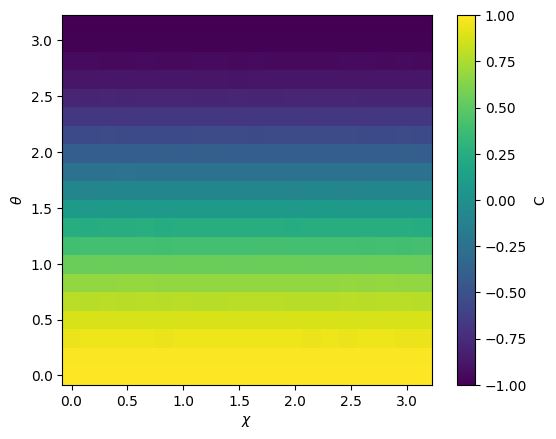

In [56]:
def counts_ignoring_qubit2(counts, bitstring):
    """量子ビットCが0と1の場合のカウントを足す"""

    return counts.get(f'0{bitstring}', 0) + counts.get(f'1{bitstring}', 0)

# それぞれの(theta, chi)ペアについてCの値を計算する
c_values_ghz = np.zeros((ntheta, nchi), dtype=float)
for icirc, idx in enumerate(np.ndindex(ntheta, nchi)):

    counts = result_ghz[icirc].data.meas.get_counts()

    ##################
    ### EDIT BELOW ###
    ##################

    c_values_ghz[idx] = counts_ignoring_qubit2(counts, '00') + counts_ignoring_qubit2(counts, '11') - counts_ignoring_qubit2(counts, '01')- counts_ignoring_qubit2(counts, '10')

    ##################
    ### EDIT ABOVE ###
    ##################
c_values_ghz /= shots

# imshow()を使って2次元プロットを作る
# imshow()は原点を左上の角に置くので、c_valuesのtheta次元は反転させる必要がある
plt.imshow(c_values_ghz[::-1], extent=(chis[0] - dchi, chis[-1] + dchi, thetas[0] - dtheta, thetas[-1] + dtheta))
plt.xlabel(r'$\chi$')
plt.ylabel(r'$\theta$')
plt.colorbar(label='C');

計算したc_values_ghzから総当たりで$|S|$の最大値を計算してみましょう。

In [57]:
max_abs_s = 0.

# 全インデックスの組み合わせを総当たりするため、ndindexを使う
for ikappa, ilambda, imu, inu in np.ndindex(ntheta, nchi, ntheta, nchi):
    abs_s = abs(c_values_ghz[ikappa, ilambda] - c_values_ghz[ikappa, inu] + c_values_ghz[imu, ilambda] + c_values_ghz[imu, inu])
    max_abs_s = max(abs_s, max_abs_s)

print(f'max |S| = {max_abs_s}')

max |S| = 2.0126


**提出するもの**

- 問題1, 2, 3において完成した回路のコード（EDIT BELOW / EDIT ABOVEの間を埋める）とシミュレーション結果によるプロット
- おまけ（評価対象外）：問題３で、量子ビットCをどのような基底で測定しても、その結果を無視する限りにおいて$C$の値は変わらないということの証明
- おまけ（評価対象外）：問題３で、量子ビットCをある基底で測定し、その結果が0であった時のみを考慮すると、ABにベル状態を回復することができる。そのような基底の同定と、問題３のように量子回路を組んで問題２と同じプロットが得られることの確認

# 考察
1.

2.

3.
